<a href="https://colab.research.google.com/github/SINDHUJA7360/AutoOMR-ScoringSystem/blob/main/ECG_SignalLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫀 ECG-SignalLab: Raw Data Preprocessing Master Pipeline

**Role:** Expert Biomedical Signal Processing Engineer  

**Pipeline Flow:**
```
Setup → Data Acquisition → Denoising → Feature Extraction → Visualization → Evaluation
```

| Stage | Description |
|---|---|
| 1 | Environment Setup & Dependency Installation |
| 2 | Kaggle API + Dataset Download (MIT-BIH / PTB) |
| 3 | Signal Engineering Pipeline (Filters + Pan-Tompkins) |
| 4 | Analytics, PSD, SNR, MSE Evaluation |
| 5 | Multi-Plot Dashboard |


---
## ⚙️ STAGE 1 — Environment Setup & Dependency Installation

In [ ]:
import subprocess, sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

packages = ['wfdb', 'biosppy', 'kaggle', 'scipy', 'numpy', 'matplotlib', 'pandas']
for pkg in packages:
    install(pkg)
    print(f'  ✅ {pkg} installed')
print('\n🎉 All dependencies installed successfully!')


  ✅ wfdb installed
  ✅ biosppy installed
  ✅ kaggle installed
  ✅ scipy installed
  ✅ numpy installed
  ✅ matplotlib installed
  ✅ pandas installed

🎉 All dependencies installed successfully!


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import scipy
import scipy.signal as signal
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, iirnotch, welch, find_peaks
from scipy.interpolate import interp1d
from typing import Optional, Tuple, List, Union
import wfdb
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'axes.titlecolor': '#e6edf3', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'grid.linewidth': 0.6, 'text.color': '#e6edf3',
    'font.family': 'monospace',
})

print('📦 All imports successful.')
print(f'   NumPy  : {np.__version__}')
print(f'   SciPy  : {scipy.__version__}')
print(f'   Pandas : {pd.__version__}')
print(f'   WFDB   : {wfdb.__version__}')


📦 All imports successful.
   NumPy  : 2.0.2
   SciPy  : 1.16.3
   Pandas : 3.0.2
   WFDB   : 4.3.1


---
## 📁 STAGE 2 — Data Acquisition

In [ ]:
# Google Drive mount (Colab only)
try:
    from google.colab import drive
    COLAB_ENV = True
    print('🔧 Google Colab environment detected.')
    mount_choice = input('Mount Google Drive? (y/n): ').strip().lower()
    if mount_choice == 'y':
        drive.mount('/content/drive')
        print('✅ Google Drive mounted at /content/drive')
except ImportError:
    COLAB_ENV = False
    print('💻 Running in local/Jupyter environment.')


🔧 Google Colab environment detected.
Mount Google Drive? (y/n): y
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive


In [ ]:
def setup_kaggle_api(username: str, api_key: str) -> bool:
    """Configure Kaggle credentials.

    Args:
        username: Kaggle account username.
        api_key:  Kaggle API key from Account settings.

    Returns:
        True if credentials saved successfully.
    """
    kaggle_dir = os.path.expanduser('~/.kaggle')
    os.makedirs(kaggle_dir, exist_ok=True)
    creds = {'username': username, 'key': api_key}
    creds_path = os.path.join(kaggle_dir, 'kaggle.json')
    with open(creds_path, 'w') as f:
        json.dump(creds, f)
    os.chmod(creds_path, 0o600)
    print(f'✅ Kaggle credentials saved to {creds_path}')
    return True


def download_kaggle_dataset(dataset_slug: str, output_dir: str = '/content/ecg_data') -> str:
    """Download a Kaggle dataset programmatically.

    Args:
        dataset_slug: e.g. 'shayanfazeli/heartbeat'
        output_dir:   Local extraction directory.

    Returns:
        Path to extracted directory.
    """
    os.makedirs(output_dir, exist_ok=True)
    cmd = f'kaggle datasets download -d {dataset_slug} -p {output_dir} --unzip'
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode == 0:
        print(f'✅ Dataset downloaded to: {output_dir}')
        print(f'   Files: {os.listdir(output_dir)[:10]}')
    else:
        print(f'⚠️  Kaggle error: {result.stderr}')
    return output_dir


# ─── FILL IN YOUR CREDENTIALS BELOW ──────────────────────────────────────────
# KAGGLE_USERNAME = 'your_username'
# KAGGLE_API_KEY  = 'your_api_key'
# setup_kaggle_api(KAGGLE_USERNAME, KAGGLE_API_KEY)
# download_kaggle_dataset('shayanfazeli/heartbeat')
print('ℹ️  Kaggle cell ready. Uncomment and fill credentials above to use.')


ℹ️  Kaggle cell ready. Uncomment and fill credentials above to use.


In [ ]:
def download_physionet_record(
    record_name: str = '100',
    database: str = 'mitdb',
    output_dir: str = '/content/physionet_data'
) -> str:
    """Download a PhysioNet wfdb record.

    Args:
        record_name: e.g. '100' for MIT-BIH record 100.
        database:    PhysioNet DB (mitdb, ptbdb, etc.).
        output_dir:  Local download directory.

    Returns:
        Full path to the downloaded record.
    """
    os.makedirs(output_dir, exist_ok=True)
    print(f'⬇️  Downloading {record_name} from PhysioNet ({database})...')
    wfdb.dl_database(database, dl_dir=output_dir, records=[record_name])
    record_path = os.path.join(output_dir, record_name)
    print(f'✅ Record saved: {record_path}')
    return record_path


RECORD_PATH = download_physionet_record(record_name='100', database='mitdb')
print(f'\n📄 Record path: {RECORD_PATH}')


⬇️  Downloading 100 from PhysioNet (mitdb)...
Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
✅ Record saved: /content/physionet_data/100

📄 Record path: /content/physionet_data/100


In [ ]:
def load_ecg_signal(
    record_path: str,
    channel: int = 0,
    sampfrom: int = 0,
    sampto: Optional[int] = None,
    csv_col: Optional[str] = None
) -> Tuple[np.ndarray, int, Optional[np.ndarray]]:
    """Load ECG signal from wfdb (.dat/.hea) or CSV format.

    Handles NaN values via linear interpolation and supports any fs.

    Args:
        record_path: Path to wfdb record (no extension) or .csv file.
        channel:     Lead index (0 = MLII for MIT-BIH).
        sampfrom:    Start sample index.
        sampto:      End sample index. None = full record.
        csv_col:     CSV column name; None = first numeric column.

    Returns:
        (signal_array, sampling_frequency, annotations_or_None)
    """
    annotations = None

    if record_path.endswith('.csv'):
        df = pd.read_csv(record_path)
        if csv_col and csv_col in df.columns:
            sig = df[csv_col].values.astype(float)
        else:
            sig = df.select_dtypes(include=np.number).iloc[:, 0].values.astype(float)
        fs = 360
        print(f'📊 CSV loaded | shape={sig.shape} | fs={fs} Hz (default)')
    else:
        kwargs = {'sampfrom': sampfrom}
        if sampto:
            kwargs['sampto'] = sampto
        record = wfdb.rdrecord(record_path, channels=[channel], **kwargs)
        sig = record.p_signal[:, 0].astype(float)
        fs  = record.fs
        print(f'📡 WFDB | record={os.path.basename(record_path)} | '
              f'channel={record.sig_name[0]} | fs={fs} Hz | samples={len(sig)}')
        try:
            ann = wfdb.rdann(record_path, 'atr', sampfrom=sampfrom,
                             sampto=sampto if sampto else record.sig_len)
            annotations = ann.sample
            print(f'   Annotations: {len(annotations)} beats loaded')
        except Exception:
            print('   Annotations: none')

    # ── NaN handling via linear interpolation ─────────────────────────────
    nan_count = np.sum(np.isnan(sig))
    if nan_count > 0:
        print(f'⚠️  {nan_count} NaN values found — interpolating...')
        valid = np.where(~np.isnan(sig))[0]
        if len(valid) > 1:
            fn = interp1d(valid, sig[valid], kind='linear',
                          bounds_error=False, fill_value='extrapolate')
            sig = fn(np.arange(len(sig)))
        else:
            sig = np.nan_to_num(sig, nan=0.0)
        print(f'   Remaining NaNs: {np.sum(np.isnan(sig))}')

    return sig, int(fs), annotations


# Load first 30 seconds (30 × 360 = 10800 samples for MIT-BIH)
raw_signal, FS, annotations = load_ecg_signal(
    RECORD_PATH, channel=0, sampfrom=0, sampto=10800
)
print(f'\n✅ Signal ready | Fs={FS} Hz | Duration={len(raw_signal)/FS:.1f}s | Nyquist={FS//2} Hz')


📡 WFDB | record=100 | channel=MLII | fs=360 Hz | samples=10800
   Annotations: 38 beats loaded

✅ Signal ready | Fs=360 Hz | Duration=30.0s | Nyquist=180 Hz


---
## 🔧 STAGE 3 — Signal Engineering Pipeline

In [ ]:
def remove_baseline_wander(
    ecg: np.ndarray, fs: int, cutoff: float = 0.5, order: int = 4
) -> np.ndarray:
    """Remove baseline wander using a high-pass Butterworth filter.

    Dynamically computes Nyquist from fs for any sampling rate.

    Args:
        ecg:    Raw ECG signal (mV).
        fs:     Sampling frequency in Hz.
        cutoff: High-pass cutoff frequency (default 0.5 Hz).
        order:  Filter order (default 4).

    Returns:
        Baseline-corrected ECG signal.
    """
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='high', analog=False)
    filtered = filtfilt(b, a, ecg)
    print(f'  [BW Removal] Order-{order} HP Butterworth | cutoff={cutoff} Hz | '
          f'Nyquist={nyq} Hz | normalized={norm_cutoff:.4f}')
    return filtered


ecg_no_bw = remove_baseline_wander(raw_signal, FS)
print('✅ Baseline wander removed.')


  [BW Removal] Order-4 HP Butterworth | cutoff=0.5 Hz | Nyquist=180.0 Hz | normalized=0.0028
✅ Baseline wander removed.


In [ ]:
def apply_notch_filter(
    ecg: np.ndarray, fs: int, notch_freq: float = 50.0, quality_factor: float = 30.0
) -> np.ndarray:
    """Suppress powerline interference via IIR notch filter.

    Args:
        ecg:            ECG signal array.
        fs:             Sampling frequency in Hz.
        notch_freq:     Centre frequency (50 or 60 Hz).
        quality_factor: Q-factor (higher = narrower notch).

    Returns:
        Notch-filtered ECG signal.

    Raises:
        ValueError: If notch_freq >= Nyquist frequency.
    """
    nyq = fs / 2.0
    if notch_freq >= nyq:
        raise ValueError(f'notch_freq {notch_freq} Hz >= Nyquist {nyq} Hz')
    b, a = iirnotch(notch_freq, quality_factor, fs=fs)
    filtered = filtfilt(b, a, ecg)
    bw = notch_freq / quality_factor
    print(f'  [Notch] Freq={notch_freq} Hz | Q={quality_factor} | '
          f'BW={bw:.2f} Hz | Nyquist={nyq} Hz')
    return filtered


POWERLINE_FREQ = 50  # ← Change to 60 for USA/Canada (60 Hz grid)
ecg_notch = apply_notch_filter(ecg_no_bw, FS, notch_freq=POWERLINE_FREQ)
print(f'✅ Notch filter applied at {POWERLINE_FREQ} Hz.')


  [Notch] Freq=50 Hz | Q=30.0 | BW=1.67 Hz | Nyquist=180.0 Hz
✅ Notch filter applied at 50 Hz.


In [ ]:
def apply_qrs_bandpass(
    ecg: np.ndarray, fs: int, low_cut: float = 5.0, high_cut: float = 15.0, order: int = 4
) -> np.ndarray:
    """Isolate QRS complex via bandpass Butterworth filter (5-15 Hz).

    Suppresses P/T-waves and EMG noise. Auto-recalculates for any fs.

    Args:
        ecg:      ECG signal.
        fs:       Sampling frequency in Hz.
        low_cut:  Lower passband edge in Hz (default 5.0).
        high_cut: Upper passband edge in Hz (default 15.0).
        order:    Butterworth order (default 4).

    Returns:
        QRS-bandpass-filtered signal.
    """
    nyq = fs / 2.0
    low  = low_cut / nyq
    high = min(high_cut / nyq, 0.999)
    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    filtered = filtfilt(b, a, ecg)
    print(f'  [QRS BP] {low_cut}-{high_cut} Hz | Order={order} | '
          f'Nyquist={nyq} Hz | norm=[{low:.4f}, {high:.4f}]')
    return filtered


ecg_bandpass = apply_qrs_bandpass(ecg_notch, FS)
print('✅ QRS bandpass filter applied.')


  [QRS BP] 5.0-15.0 Hz | Order=4 | Nyquist=180.0 Hz | norm=[0.0278, 0.0833]
✅ QRS bandpass filter applied.


In [ ]:
def pan_tompkins_detector(
    ecg: np.ndarray, fs: int, refractory_ms: float = 200.0
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Pan-Tompkins QRS detection algorithm.

    Pipeline: Differentiation → Squaring → Moving-Avg Integration
    → Adaptive Threshold → Refractory Blanking → Peak Refinement.

    Args:
        ecg:             QRS-bandpass-filtered ECG signal.
        fs:              Sampling frequency in Hz.
        refractory_ms:   Post-detection blanking window in ms.

    Returns:
        (r_peaks, differentiated, squared, integrated) arrays.
    """
    # Step 1: Differentiation (slope accentuation)
    diff_ecg = np.diff(ecg, prepend=ecg[0])

    # Step 2: Squaring (polarity resolution + amplification)
    squared = diff_ecg ** 2

    # Step 3: Moving Window Integration (~150 ms)
    win_size = int(0.15 * fs)
    kernel   = np.ones(win_size) / win_size
    integrated = np.convolve(squared, kernel, mode='same')

    # Step 4: Adaptive threshold + peak detection
    refractory_samples = int(refractory_ms * fs / 1000.0)
    threshold = 0.5 * np.mean(integrated)
    r_peaks, _ = find_peaks(integrated, height=threshold, distance=refractory_samples)

    # Step 5: Refine peaks to actual ECG maxima (50 ms window)
    half_win = int(0.05 * fs)
    refined = []
    for pk in r_peaks:
        lo = max(0, pk - half_win)
        hi = min(len(ecg) - 1, pk + half_win)
        refined.append(lo + np.argmax(np.abs(ecg[lo:hi])))
    refined = np.array(refined)

    print(f'  [Pan-Tompkins] Win={win_size} samp ({0.15*1000:.0f}ms) | '
          f'Refractory={refractory_samples} samp | '
          f'Threshold={threshold:.6f} | R-peaks={len(refined)}')
    return refined, diff_ecg, squared, integrated


r_peaks, ecg_diff, ecg_squared, ecg_integrated = pan_tompkins_detector(ecg_bandpass, FS)

if len(r_peaks) > 1:
    rr = np.diff(r_peaks) / FS
    print(f'\n💓 Heart Rate : {60.0/np.mean(rr):.1f} BPM')
    print(f'   HRV (SDNN) : {np.std(rr)*1000:.2f} ms')
    print(f'   Mean RR    : {np.mean(rr)*1000:.1f} ms')
print('\n✅ Pan-Tompkins detection complete.')


  [Pan-Tompkins] Win=54 samp (150ms) | Refractory=72 samp | Threshold=0.000171 | R-peaks=37

💓 Heart Rate : 74.0 BPM
   HRV (SDNN) : 47.29 ms
   Mean RR    : 811.3 ms

✅ Pan-Tompkins detection complete.


In [ ]:
def zscore_standardize(ecg: np.ndarray) -> np.ndarray:
    """Z-score standardization: (x - mean) / std.

    Args:
        ecg: Input ECG signal.

    Returns:
        Signal with zero mean and unit variance.
    """
    return (ecg - np.mean(ecg)) / (np.std(ecg) + 1e-10)


def minmax_normalize(
    ecg: np.ndarray, feature_range: Tuple[float, float] = (-1.0, 1.0)
) -> np.ndarray:
    """Min-Max normalization to a target range.

    Args:
        ecg:           Input ECG signal.
        feature_range: Output (min, max) range.

    Returns:
        Normalized signal.
    """
    lo, hi = feature_range
    x_min, x_max = ecg.min(), ecg.max()
    if x_max - x_min < 1e-10:
        return np.zeros_like(ecg)
    return ((ecg - x_min) / (x_max - x_min)) * (hi - lo) + lo


ecg_zscore = zscore_standardize(ecg_notch)
ecg_minmax = minmax_normalize(ecg_notch)
print('Z-score : mean={:.4f}  std={:.4f}'.format(np.mean(ecg_zscore), np.std(ecg_zscore)))
print('Min-Max : min={:.4f}   max={:.4f}'.format(ecg_minmax.min(), ecg_minmax.max()))
print('✅ Feature scaling complete.')


Z-score : mean=0.0000  std=1.0000
Min-Max : min=-1.0000   max=1.0000
✅ Feature scaling complete.


---
## 📊 STAGE 4 — Analytics & Quality Metrics

In [ ]:
def calculate_snr(clean: np.ndarray, noisy: np.ndarray) -> float:
    """Signal-to-Noise Ratio in dB: 10*log10(signal_power / noise_power).

    Args:
        clean: Filtered signal.
        noisy: Raw (noisy) signal.

    Returns:
        SNR in dB.
    """
    n = min(len(clean), len(noisy))
    noise = noisy[:n] - clean[:n]
    sig_p  = np.mean(clean[:n] ** 2)
    noi_p  = np.mean(noise ** 2)
    return 10.0 * np.log10(sig_p / noi_p) if noi_p > 1e-15 else float('inf')


def calculate_mse(a: np.ndarray, b: np.ndarray) -> float:
    """Mean Squared Error between two signals.

    Args:
        a: Reference signal.
        b: Comparison signal.

    Returns:
        MSE value.
    """
    n = min(len(a), len(b))
    return float(np.mean((a[:n] - b[:n]) ** 2))


df_metrics = pd.DataFrame({
    'Stage': ['Raw Signal', 'After HP Filter', 'After Notch', 'After QRS BP',
              'Z-score', 'Min-Max'],
    'Mean':    [np.mean(raw_signal), np.mean(ecg_no_bw), np.mean(ecg_notch),
                np.mean(ecg_bandpass), np.mean(ecg_zscore), np.mean(ecg_minmax)],
    'Std Dev': [np.std(raw_signal), np.std(ecg_no_bw), np.std(ecg_notch),
                np.std(ecg_bandpass), np.std(ecg_zscore), np.std(ecg_minmax)],
    'SNR vs Raw (dB)': [0.0,
        calculate_snr(ecg_no_bw, raw_signal),
        calculate_snr(ecg_notch, raw_signal),
        calculate_snr(ecg_bandpass, raw_signal),
        calculate_snr(ecg_zscore, zscore_standardize(raw_signal)),
        calculate_snr(ecg_minmax, minmax_normalize(raw_signal))],
    'MSE vs Prev': [0.0,
        calculate_mse(raw_signal, ecg_no_bw),
        calculate_mse(ecg_no_bw, ecg_notch),
        calculate_mse(ecg_notch, ecg_bandpass),
        0.0, 0.0],
}).round(6)

print('\n🔬 Signal Quality Metrics:')
print('='*72)
print(df_metrics.to_string(index=False))
print('='*72)



🔬 Signal Quality Metrics:
          Stage      Mean  Std Dev  SNR vs Raw (dB)  MSE vs Prev
     Raw Signal -0.335366 0.173697         0.000000     0.000000
After HP Filter -0.000336 0.169578        -5.970963     0.113720
    After Notch -0.000335 0.169377        -5.981977     0.000018
   After QRS BP  0.000034 0.105364       -10.629932     0.014379
        Z-score  0.000000 1.000000        13.000933     0.000000
        Min-Max -0.651154 0.197461        20.166579     0.000000


In [ ]:
def compute_psd(
    ecg: np.ndarray, fs: int, nperseg: Optional[int] = None, label: str = 'ECG'
) -> Tuple[np.ndarray, np.ndarray]:
    """Estimate PSD using Welch's method.

    Args:
        ecg:     ECG signal.
        fs:      Sampling frequency.
        nperseg: Samples per Welch segment (default: fs*2).
        label:   Descriptive label.

    Returns:
        (frequencies, power_density) arrays.
    """
    if nperseg is None:
        nperseg = min(len(ecg), fs * 2)
    freqs, psd = welch(ecg, fs=fs, nperseg=nperseg, window='hann', average='median')
    print(f'  [PSD] {label} | segments={nperseg} | freq_res={freqs[1]-freqs[0]:.4f} Hz')
    return freqs, psd


freqs_raw,      psd_raw      = compute_psd(raw_signal,   FS, label='Raw')
freqs_filtered, psd_filtered = compute_psd(ecg_notch,    FS, label='Filtered')
freqs_bandpass, psd_bandpass = compute_psd(ecg_bandpass, FS, label='QRS Bandpass')
print('✅ PSD computed for all stages.')


  [PSD] Raw | segments=720 | freq_res=0.5000 Hz
  [PSD] Filtered | segments=720 | freq_res=0.5000 Hz
  [PSD] QRS Bandpass | segments=720 | freq_res=0.5000 Hz
✅ PSD computed for all stages.


---
## 📈 STAGE 5 — Multi-Plot Visualization Dashboard

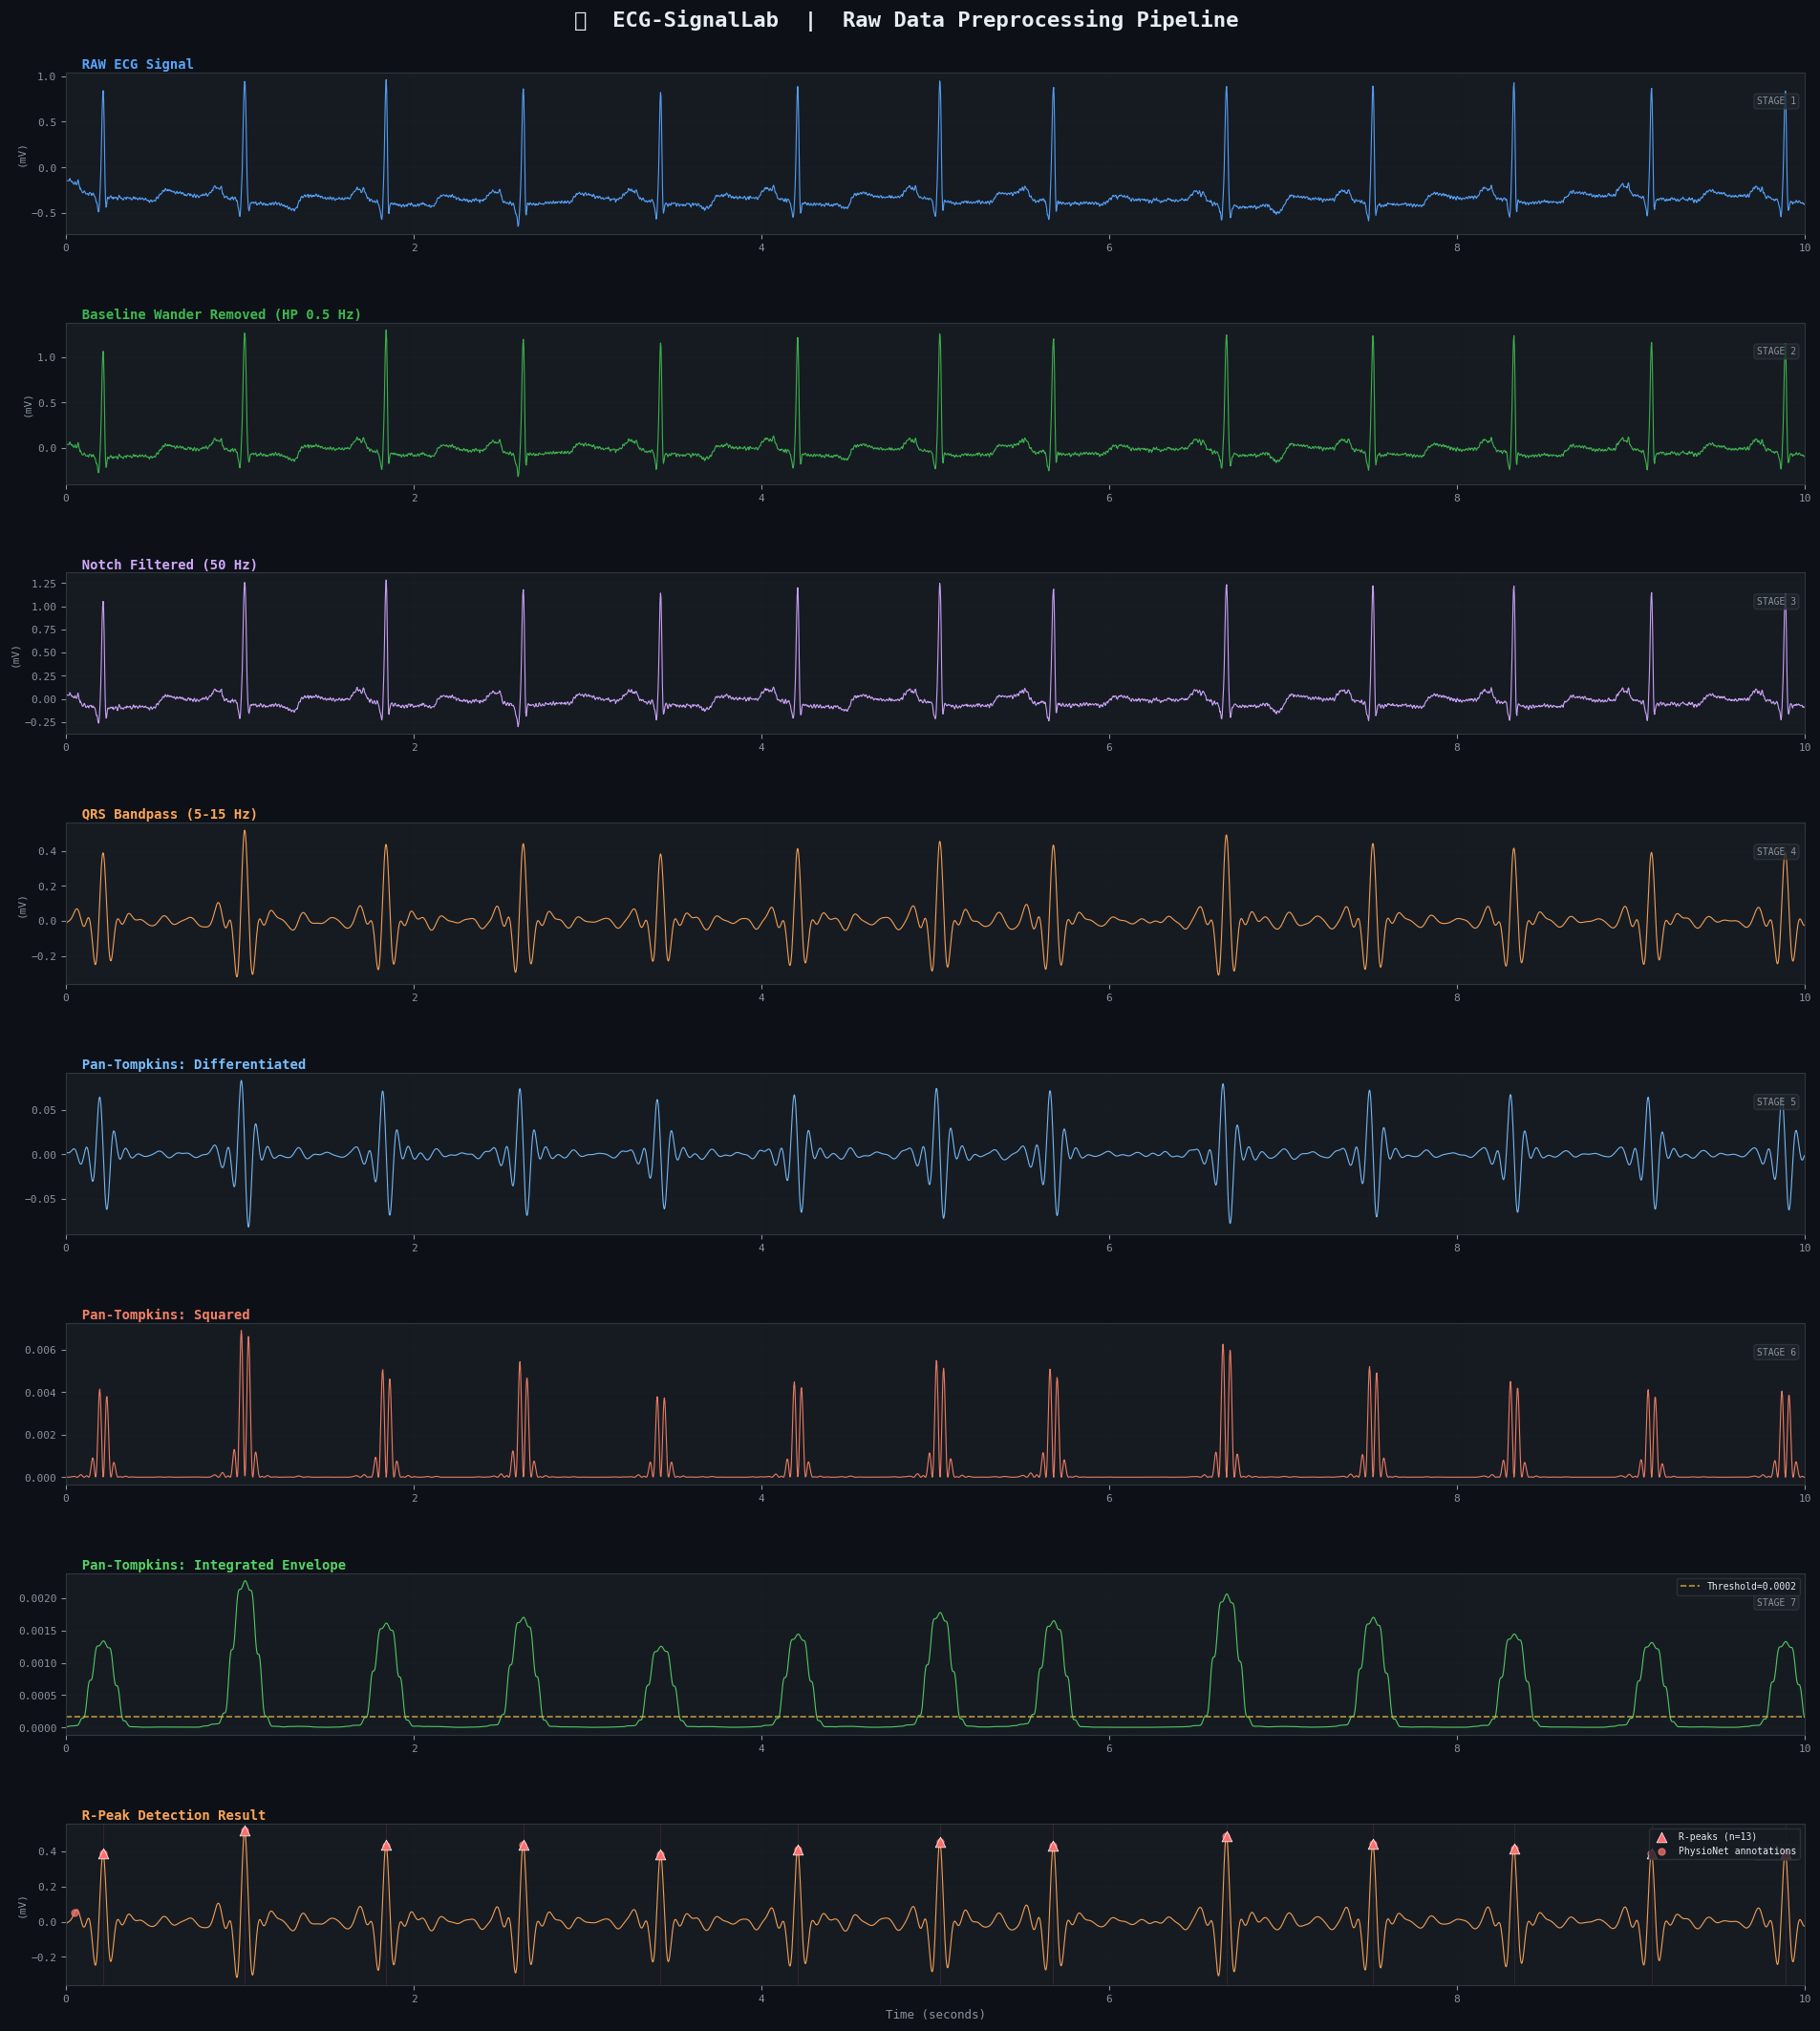

✅ Dashboard saved: /content/ecg_dashboard.png


In [ ]:
def plot_ecg_dashboard(raw, ecg_hp, ecg_nt, ecg_bp, ecg_diff, ecg_sq, ecg_int,
                        r_peaks, fs, display_seconds=10.0):
    """8-panel ECG pipeline dashboard.

    Shows every processing stage from raw acquisition through Pan-Tompkins
    R-peak detection in a single dark-themed figure.

    Args:
        raw, ecg_hp, ecg_nt, ecg_bp: Signal stages.
        ecg_diff, ecg_sq, ecg_int:   Pan-Tompkins intermediate signals.
        r_peaks:                     Detected R-peak indices.
        fs:                          Sampling frequency.
        display_seconds:             Time window to render.
    """
    n = int(display_seconds * fs)
    t = np.arange(n) / fs
    C = {'raw': '#58a6ff', 'hp': '#3fb950', 'notch': '#d2a8ff',
         'bp': '#ffa657', 'diff': '#79c0ff', 'sq': '#f78166',
         'intg': '#56d364', 'peak': '#ff6e6e', 'thresh': '#e3b341', 'ann': '#ff7b72'}

    fig = plt.figure(figsize=(20, 22), facecolor='#0d1117')
    fig.suptitle('🫀  ECG-SignalLab  |  Raw Data Preprocessing Pipeline',
                 fontsize=16, fontweight='bold', color='#e6edf3', y=0.98)
    gs = gridspec.GridSpec(8, 1, figure=fig, hspace=0.55,
                           left=0.06, right=0.97, top=0.95, bottom=0.04)

    panels = [
        (raw[:n],      C['raw'],   'RAW ECG Signal',                      '(mV)'),
        (ecg_hp[:n],   C['hp'],    'Baseline Wander Removed (HP 0.5 Hz)', '(mV)'),
        (ecg_nt[:n],   C['notch'], f'Notch Filtered ({POWERLINE_FREQ} Hz)','(mV)'),
        (ecg_bp[:n],   C['bp'],    'QRS Bandpass (5-15 Hz)',               '(mV)'),
        (ecg_diff[:n], C['diff'],  'Pan-Tompkins: Differentiated',        ''),
        (ecg_sq[:n],   C['sq'],    'Pan-Tompkins: Squared',               ''),
        (ecg_int[:n],  C['intg'],  'Pan-Tompkins: Integrated Envelope',   ''),
        (ecg_bp[:n],   C['bp'],    'R-Peak Detection Result',             '(mV)'),
    ]

    axes = []
    for i, (data, color, title, ylabel) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.plot(t, data, color=color, linewidth=0.8, alpha=0.95)
        ax.set_title(f'  {title}', loc='left', fontsize=10,
                     color=color, fontweight='bold', pad=3)
        if ylabel:
            ax.set_ylabel(ylabel, fontsize=8, color='#8b949e')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, display_seconds)
        ax.tick_params(labelsize=8)
        ax.text(0.995, 0.85, f'STAGE {i+1}', transform=ax.transAxes,
                fontsize=7, color='#8b949e', ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d',
                          edgecolor='#30363d', alpha=0.8))
        axes.append(ax)

    # Threshold line on integration panel
    thresh = 0.5 * np.mean(ecg_int)
    axes[6].axhline(thresh, color=C['thresh'], linewidth=1.2, linestyle='--',
                    alpha=0.8, label=f'Threshold={thresh:.4f}')
    axes[6].legend(fontsize=7, loc='upper right',
                   facecolor='#161b22', edgecolor='#30363d')

    # R-peaks overlay
    vis_peaks = r_peaks[r_peaks < n]
    if len(vis_peaks):
        axes[7].scatter(vis_peaks / fs, ecg_bp[vis_peaks],
                        color=C['peak'], s=60, zorder=5, marker='^',
                        edgecolors='white', linewidths=0.5,
                        label=f'R-peaks (n={len(vis_peaks)})')
        for pk in vis_peaks:
            axes[7].axvline(pk / fs, color=C['peak'], alpha=0.15, linewidth=0.6)
    if annotations is not None:
        vis_ann = annotations[annotations < n]
        axes[7].scatter(vis_ann / fs, ecg_bp[vis_ann],
                        color=C['ann'], s=25, zorder=4, marker='o',
                        alpha=0.7, label='PhysioNet annotations')
    axes[7].legend(fontsize=7, loc='upper right',
                   facecolor='#161b22', edgecolor='#30363d')
    axes[-1].set_xlabel('Time (seconds)', fontsize=9, color='#8b949e')

    plt.savefig('/content/ecg_dashboard.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print('✅ Dashboard saved: /content/ecg_dashboard.png')


plot_ecg_dashboard(raw_signal, ecg_no_bw, ecg_notch, ecg_bandpass,
                   ecg_diff, ecg_squared, ecg_integrated, r_peaks, FS)

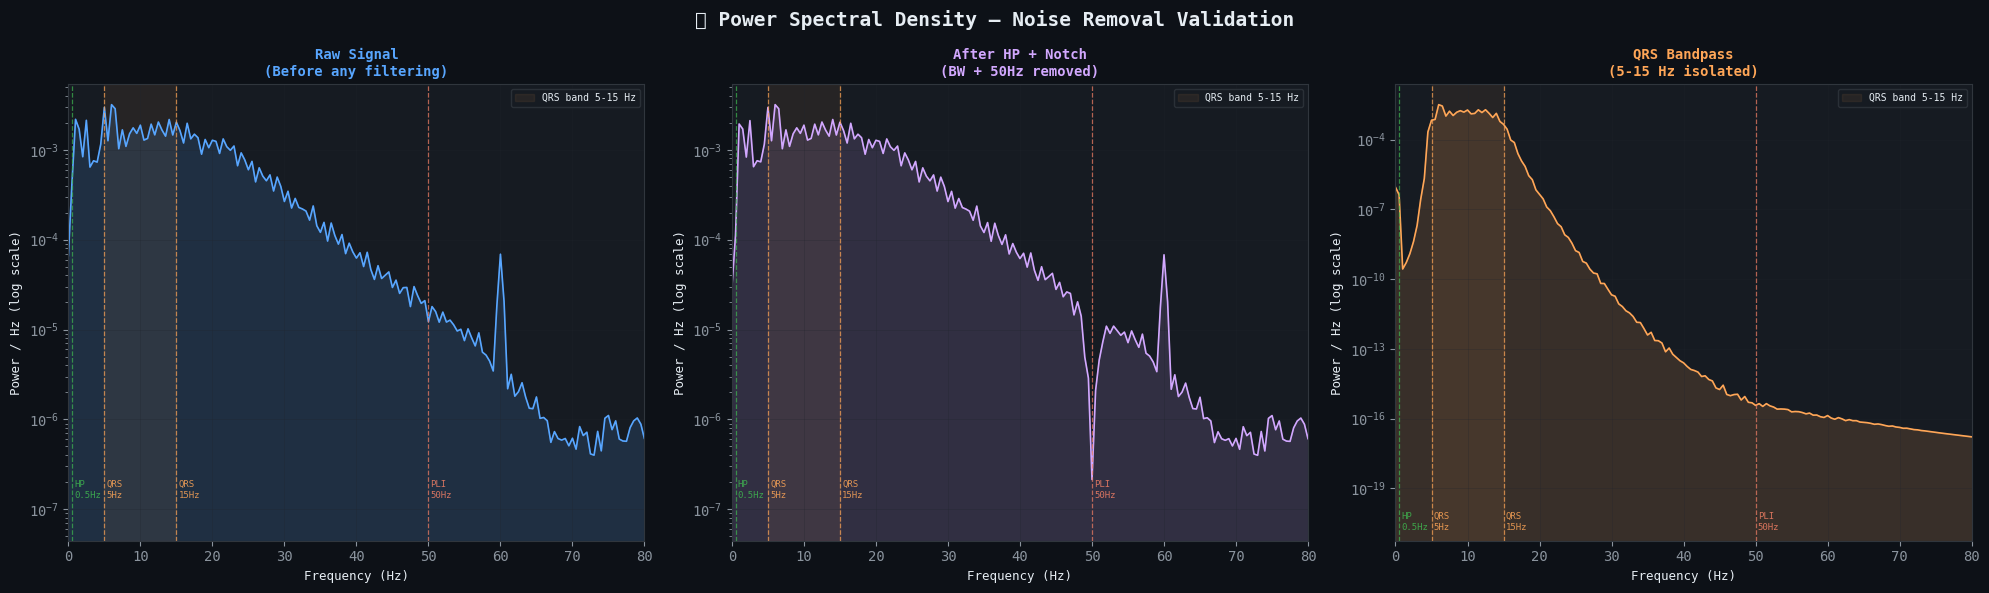

✅ PSD dashboard saved: /content/ecg_psd.png


In [ ]:
def plot_psd_dashboard(freqs_raw, psd_raw, freqs_filt, psd_filt,
                        freqs_bp, psd_bp, powerline_freq=50):
    """PSD comparison dashboard for noise removal validation.

    Three panels showing how energy at 0-0.5 Hz and powerline
    frequency is attenuated across filter stages.

    Args:
        freqs_raw, psd_raw:    Raw signal PSD.
        freqs_filt, psd_filt:  Post-notch PSD.
        freqs_bp, psd_bp:      QRS bandpass PSD.
        powerline_freq:        50 or 60 Hz annotation.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0d1117')
    fig.suptitle('🔬 Power Spectral Density — Noise Removal Validation',
                 fontsize=14, color='#e6edf3', fontweight='bold')

    datasets = [
        (freqs_raw,  psd_raw,  '#58a6ff', 'Raw Signal',       '(Before any filtering)'),
        (freqs_filt, psd_filt, '#d2a8ff', 'After HP + Notch', f'(BW + {powerline_freq}Hz removed)'),
        (freqs_bp,   psd_bp,   '#ffa657', 'QRS Bandpass',     '(5-15 Hz isolated)'),
    ]
    annotations_v = [
        (0.5, '#3fb950', 'HP\n0.5Hz'), (5.0, '#ffa657', 'QRS\n5Hz'),
        (15.0, '#ffa657', 'QRS\n15Hz'), (powerline_freq, '#f78166', f'PLI\n{powerline_freq}Hz'),
    ]

    for ax, (freqs, psd, color, title, subtitle) in zip(axes, datasets):
        ax.semilogy(freqs, psd, color=color, linewidth=1.2)
        ax.fill_between(freqs, psd, alpha=0.15, color=color)
        ax.set_title(f'{title}\n{subtitle}', fontsize=10, color=color, fontweight='bold')
        ax.set_xlabel('Frequency (Hz)', fontsize=9)
        ax.set_ylabel('Power / Hz (log scale)', fontsize=9)
        ax.set_xlim(0, min(80, FS / 2))
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#161b22')
        for freq, lc, label in annotations_v:
            if freq < FS / 2:
                ax.axvline(freq, color=lc, linewidth=0.9, linestyle='--', alpha=0.7)
                ax.text(freq + 0.3, ax.get_ylim()[0] * 3,
                        label, fontsize=6.5, color=lc, alpha=0.85)
        ax.axvspan(5, 15, alpha=0.07, color='#ffa657', label='QRS band 5-15 Hz')
        ax.legend(fontsize=7, facecolor='#161b22', edgecolor='#30363d')

    plt.tight_layout()
    plt.savefig('/content/ecg_psd.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print('✅ PSD dashboard saved: /content/ecg_psd.png')


plot_psd_dashboard(freqs_raw, psd_raw, freqs_filtered, psd_filtered,
                   freqs_bandpass, psd_bandpass, powerline_freq=POWERLINE_FREQ)


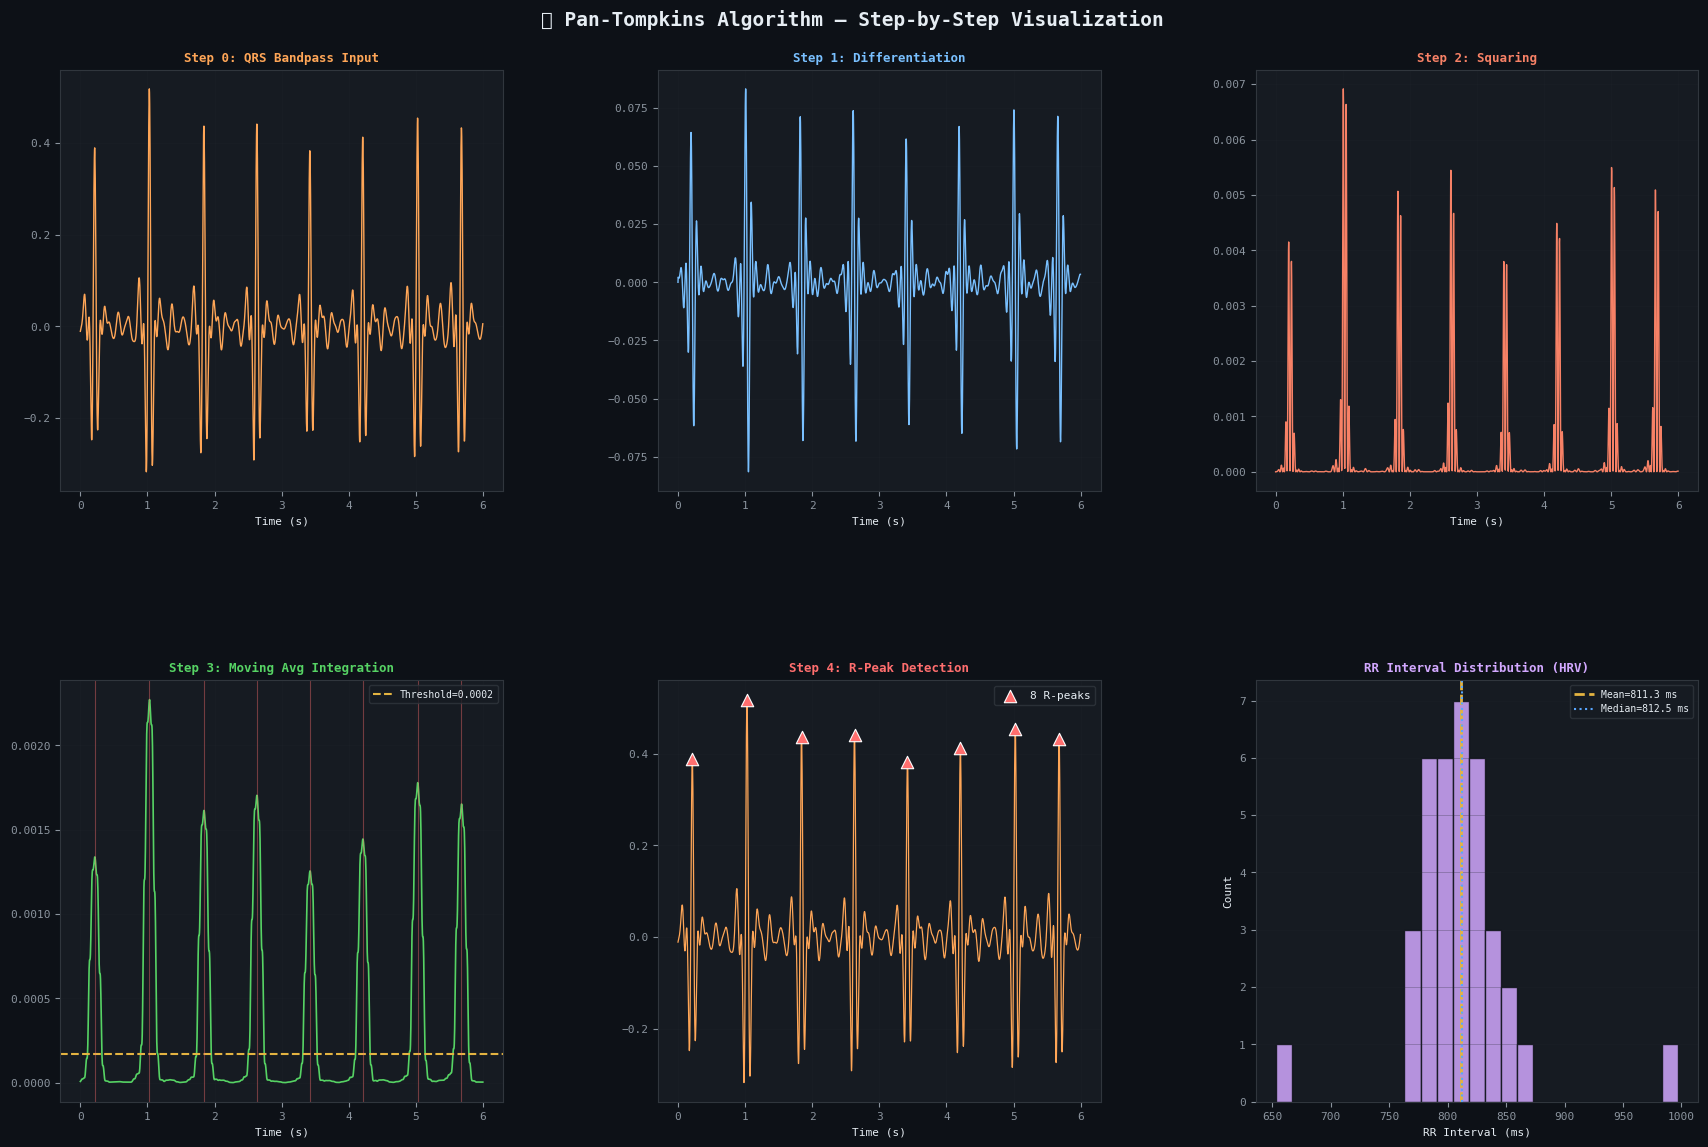

✅ Pan-Tompkins figure saved: /content/ecg_pantompkins.png


In [ ]:
def plot_pantompkins_and_rr(ecg_bp, ecg_diff, ecg_sq, ecg_int,
                              r_peaks, fs, display_seconds=6.0):
    """Step-by-step Pan-Tompkins visualization + RR interval histogram.

    Six panels: input, differentiation, squaring, integration,
    peak detection, and RR distribution.

    Args:
        ecg_bp, ecg_diff, ecg_sq, ecg_int: Pan-Tompkins signals.
        r_peaks:            Detected R-peak indices.
        fs:                 Sampling frequency.
        display_seconds:    Time window.
    """
    n = int(display_seconds * fs)
    t = np.arange(n) / fs
    vp = r_peaks[r_peaks < n]

    fig = plt.figure(figsize=(18, 12), facecolor='#0d1117')
    fig.suptitle('🔍 Pan-Tompkins Algorithm — Step-by-Step Visualization',
                 fontsize=14, color='#e6edf3', fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                           left=0.06, right=0.97, top=0.93, bottom=0.07)

    subplots = [
        (gs[0, 0], ecg_bp[:n],   '#ffa657', 'Step 0: QRS Bandpass Input'),
        (gs[0, 1], ecg_diff[:n], '#79c0ff', 'Step 1: Differentiation'),
        (gs[0, 2], ecg_sq[:n],   '#f78166', 'Step 2: Squaring'),
    ]
    axes = []
    for pos, data, color, title in subplots:
        ax = fig.add_subplot(pos)
        ax.plot(t, data, color=color, linewidth=1.0)
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.set_xlabel('Time (s)', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#161b22')
        ax.tick_params(labelsize=8)
        axes.append(ax)

    # Integration panel
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(t, ecg_int[:n], color='#56d364', linewidth=1.2)
    thresh = 0.5 * np.mean(ecg_int)
    ax4.axhline(thresh, color='#e3b341', linewidth=1.5, linestyle='--',
                label=f'Threshold={thresh:.4f}')
    for pk in vp:
        ax4.axvline(pk / fs, color='#ff6e6e', alpha=0.4, linewidth=0.8)
    ax4.set_title('Step 3: Moving Avg Integration', color='#56d364',
                  fontweight='bold', fontsize=9)
    ax4.set_xlabel('Time (s)', fontsize=8)
    ax4.legend(fontsize=7, facecolor='#161b22', edgecolor='#30363d')
    ax4.grid(True, alpha=0.3)
    ax4.set_facecolor('#161b22')
    ax4.tick_params(labelsize=8)

    # Final detection
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(t, ecg_bp[:n], color='#ffa657', linewidth=0.9)
    if len(vp):
        ax5.scatter(vp / fs, ecg_bp[vp], color='#ff6e6e', s=80, zorder=5,
                    marker='^', edgecolors='white', linewidths=0.8,
                    label=f'{len(vp)} R-peaks')
    ax5.set_title('Step 4: R-Peak Detection', color='#ff6e6e',
                  fontweight='bold', fontsize=9)
    ax5.set_xlabel('Time (s)', fontsize=8)
    ax5.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')
    ax5.grid(True, alpha=0.3)
    ax5.set_facecolor('#161b22')
    ax5.tick_params(labelsize=8)

    # RR histogram
    ax6 = fig.add_subplot(gs[1, 2])
    if len(r_peaks) > 1:
        rr_ms = np.diff(r_peaks) / fs * 1000
        ax6.hist(rr_ms, bins=25, color='#d2a8ff', edgecolor='#0d1117', alpha=0.85)
        ax6.axvline(np.mean(rr_ms), color='#e3b341', linewidth=2.0, linestyle='--',
                    label=f'Mean={np.mean(rr_ms):.1f} ms')
        ax6.axvline(np.median(rr_ms), color='#58a6ff', linewidth=1.5, linestyle=':',
                    label=f'Median={np.median(rr_ms):.1f} ms')
        ax6.set_xlabel('RR Interval (ms)', fontsize=8)
        ax6.set_ylabel('Count', fontsize=8)
        ax6.legend(fontsize=7, facecolor='#161b22', edgecolor='#30363d')
    ax6.set_title('RR Interval Distribution (HRV)', color='#d2a8ff',
                  fontweight='bold', fontsize=9)
    ax6.grid(True, alpha=0.3, axis='y')
    ax6.set_facecolor('#161b22')
    ax6.tick_params(labelsize=8)

    plt.savefig('/content/ecg_pantompkins.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print('✅ Pan-Tompkins figure saved: /content/ecg_pantompkins.png')


plot_pantompkins_and_rr(ecg_bandpass, ecg_diff, ecg_squared,
                        ecg_integrated, r_peaks, FS, display_seconds=6.0)


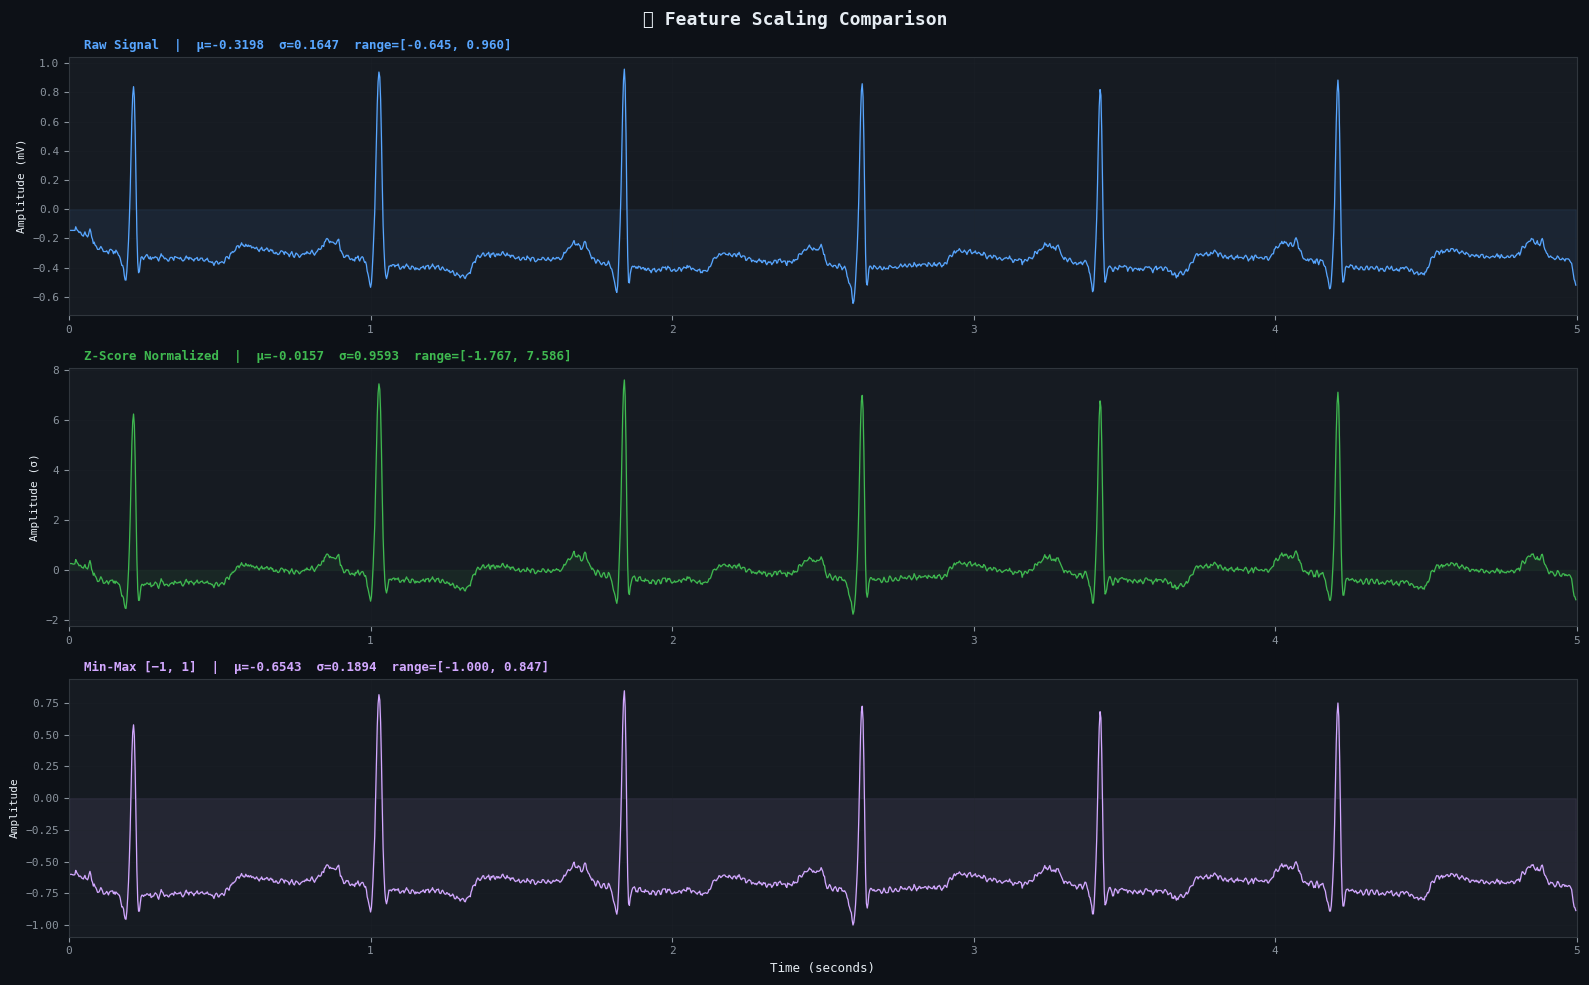

✅ Scaling comparison saved: /content/ecg_scaling.png


In [ ]:
def plot_scaling_comparison(ecg_raw, ecg_zscore, ecg_minmax, fs,
                              display_seconds=5.0):
    """Compare raw, Z-score, and Min-Max scaled signals.

    Args:
        ecg_raw, ecg_zscore, ecg_minmax: Signal variants.
        fs:              Sampling frequency.
        display_seconds: Time window to display.
    """
    n = int(display_seconds * fs)
    t = np.arange(n) / fs
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), facecolor='#0d1117')
    fig.suptitle('📏 Feature Scaling Comparison',
                 fontsize=13, color='#e6edf3', fontweight='bold')

    configs = [
        (ecg_raw,    '#58a6ff', 'Raw Signal',         'Amplitude (mV)'),
        (ecg_zscore, '#3fb950', 'Z-Score Normalized', 'Amplitude (σ)'),
        (ecg_minmax, '#d2a8ff', 'Min-Max [−1, 1]',    'Amplitude'),
    ]
    for ax, (data, color, title, ylabel) in zip(axes, configs):
        ax.plot(t, data[:n], color=color, linewidth=0.9)
        ax.fill_between(t, data[:n], alpha=0.08, color=color)
        ax.set_title(f'  {title}  |  μ={np.mean(data[:n]):.4f}  '
                     f'σ={np.std(data[:n]):.4f}  '
                     f'range=[{data[:n].min():.3f}, {data[:n].max():.3f}]',
                     loc='left', fontsize=9, color=color, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, display_seconds)
        ax.set_facecolor('#161b22')
        ax.tick_params(labelsize=8)
    axes[-1].set_xlabel('Time (seconds)', fontsize=9)

    plt.tight_layout()
    plt.savefig('/content/ecg_scaling.png', dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print('✅ Scaling comparison saved: /content/ecg_scaling.png')


plot_scaling_comparison(raw_signal, ecg_zscore, ecg_minmax, FS)

---
## 📋 STAGE 6 — Final Summary Report & Export

In [ ]:
rr = np.diff(r_peaks) / FS if len(r_peaks) > 1 else np.array([1.0])

print('\n' + '='*70)
print('          ECG-SIGNALLAB — PIPELINE SUMMARY REPORT')
print('='*70)
print(f'''
SIGNAL PROPERTIES
  Sampling Frequency  : {FS} Hz
  Nyquist Frequency   : {FS//2} Hz
  Total Samples       : {len(raw_signal):,}
  Duration            : {len(raw_signal)/FS:.2f} seconds
  Powerline Filter    : {POWERLINE_FREQ} Hz

FILTER SPECIFICATIONS
  [1] Baseline Wander : 4th-order HP Butterworth @ 0.5 Hz
  [2] Powerline Notch : IIR Notch @ {POWERLINE_FREQ} Hz (Q=30)
  [3] QRS Bandpass    : 4th-order BP Butterworth @ 5-15 Hz

PAN-TOMPKINS DETECTION
  R-Peaks Detected    : {len(r_peaks)}
  Mean Heart Rate     : {60.0/np.mean(rr):.1f} BPM
  HRV (SDNN)          : {np.std(rr)*1000:.2f} ms
  Mean RR Interval    : {np.mean(rr)*1000:.1f} ms

SIGNAL QUALITY
  SNR (Raw -> Notch)  : {calculate_snr(ecg_notch, raw_signal):.2f} dB
  SNR (Raw -> QRS BP) : {calculate_snr(ecg_bandpass, raw_signal):.2f} dB
  MSE (Raw -> Notch)  : {calculate_mse(raw_signal, ecg_notch):.6f}

OUTPUT FILES
  /content/ecg_dashboard.png    -- 8-panel pipeline plot
  /content/ecg_psd.png          -- PSD noise validation
  /content/ecg_pantompkins.png  -- Pan-Tompkins steps
  /content/ecg_scaling.png      -- Feature scaling
  /content/ecg_processed.csv    -- Processed signal export
''')
print('='*70)
print('  ECG-SignalLab pipeline completed successfully!')
print('='*70)



          ECG-SIGNALLAB — PIPELINE SUMMARY REPORT

SIGNAL PROPERTIES
  Sampling Frequency  : 360 Hz
  Nyquist Frequency   : 180 Hz
  Total Samples       : 10,800
  Duration            : 30.00 seconds
  Powerline Filter    : 50 Hz

FILTER SPECIFICATIONS
  [1] Baseline Wander : 4th-order HP Butterworth @ 0.5 Hz
  [2] Powerline Notch : IIR Notch @ 50 Hz (Q=30)
  [3] QRS Bandpass    : 4th-order BP Butterworth @ 5-15 Hz

PAN-TOMPKINS DETECTION
  R-Peaks Detected    : 37
  Mean Heart Rate     : 74.0 BPM
  HRV (SDNN)          : 47.29 ms
  Mean RR Interval    : 811.3 ms

SIGNAL QUALITY
  SNR (Raw -> Notch)  : -5.98 dB
  SNR (Raw -> QRS BP) : -10.63 dB
  MSE (Raw -> Notch)  : 0.113739

OUTPUT FILES
  /content/ecg_dashboard.png    -- 8-panel pipeline plot
  /content/ecg_psd.png          -- PSD noise validation
  /content/ecg_pantompkins.png  -- Pan-Tompkins steps
  /content/ecg_scaling.png      -- Feature scaling
  /content/ecg_processed.csv    -- Processed signal export

  ECG-SignalLab pipeli

In [ ]:
def export_processed_signals(
    raw, ecg_hp, ecg_nt, ecg_bp, ecg_z, ecg_mm, r_peaks, fs,
    output_path='/content/ecg_processed.csv'
) -> pd.DataFrame:
    """Export all pipeline stages and R-peak labels to a single CSV.

    Args:
        raw, ecg_hp, ecg_nt, ecg_bp: Signal stages (mV).
        ecg_z, ecg_mm:               Scaled variants.
        r_peaks:                     Detected R-peak indices.
        fs:                          Sampling frequency.
        output_path:                 CSV output path.

    Returns:
        DataFrame with all signal columns.
    """
    n = min(len(raw), len(ecg_hp), len(ecg_nt), len(ecg_bp))
    r_mask = np.zeros(n, dtype=int)
    r_mask[r_peaks[r_peaks < n]] = 1

    df = pd.DataFrame({
        'time_s':            np.arange(n) / fs,
        'raw_ecg_mV':        raw[:n],
        'hp_filtered_mV':    ecg_hp[:n],
        'notch_filtered_mV': ecg_nt[:n],
        'qrs_bandpass_mV':   ecg_bp[:n],
        'zscore_std':        ecg_z[:n],
        'minmax_norm':       ecg_mm[:n],
        'r_peak_label':      r_mask,
    })
    df.to_csv(output_path, index=False)
    print(f'✅ Exported {df.shape} to {output_path}')
    print(f'   R-peaks labelled: {r_mask.sum()}')
    return df


df_out = export_processed_signals(
    raw_signal, ecg_no_bw, ecg_notch, ecg_bandpass,
    ecg_zscore, ecg_minmax, r_peaks, FS
)
print('\nPreview (first 5 rows):')
df_out.head()


✅ Exported (10800, 8) to /content/ecg_processed.csv
   R-peaks labelled: 37

Preview (first 5 rows):


,time_s,raw_ecg_mV,hp_filtered_mV,notch_filtered_mV,qrs_bandpass_mV,zscore_std,minmax_norm,r_peak_label
0,0.000000,-0.145,0.039503,0.038947,-0.011145,0.231923,-0.605359,0
1,0.002778,-0.145,0.039985,0.041913,-0.008945,0.249433,-0.601901,0
2,0.005556,-0.145,0.040467,0.043567,-0.006915,0.259197,-0.599973,0
3,0.008333,-0.145,0.040950,0.043011,-0.005037,0.255917,-0.600621,0
4,0.011111,-0.145,0.041434,0.040923,-0.003262,0.243589,-0.603055,0
